In [ ]:
import os
import sys
import json
import random
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from PIL import Image
from dotenv import load_dotenv
from pathlib import Path
env_path = Path("../.env")
load_dotenv(dotenv_path=env_path)

True

In [6]:
!kaggle datasets download -d eliocordeiropereira/skin-cancer-the-ham10000-dataset --unzip -p ../data/data_ham10000

Dataset URL: https://www.kaggle.com/datasets/eliocordeiropereira/skin-cancer-the-ham10000-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)




  0%|          | 0.00/2.97G [00:00<?, ?B/s]
  0%|          | 1.00M/2.97G [00:00<45:46, 1.16MB/s]
  0%|          | 2.00M/2.97G [00:01<22:57, 2.32MB/s]
  0%|          | 4.00M/2.97G [00:01<10:50, 4.90MB/s]
  0%|          | 6.00M/2.97G [00:01<06:56, 7.66MB/s]
  0%|          | 8.00M/2.97G [00:01<06:56, 7.64MB/s]
  0%|          | 13.0M/2.97G [00:01<03:41, 14.4MB/s]
  0%|          | 15.0M/2.97G [00:01<03:29, 15.2MB/s]
  1%|          | 17.0M/2.97G [00:01<03:14, 16.3MB/s]
  1%|          | 20.0M/2.97G [00:02<02:55, 18.1MB/s]
  1%|          | 23.0M/2.97G [00:02<02:44, 19.2MB/s]
  1%|          | 26.0M/2.97G [00:02<02:40, 19.8MB/s]
  1%|          | 29.0M/2.97G [00:02<02:37, 20.0MB/s]
  1%|          | 31.0M/2.97G [00:02<02:36, 20.2MB/s]
  1%|          | 34.0M/2.97G [00:02<02:33, 20.6MB/s]
  1%|          | 37.0M/2.97G [00:02<02:32, 20.7MB/s]
  1%|▏         | 40.0M/2.97G [00:03<02:32, 20.7MB/s]
  1%|▏         | 43.0M/2.97G [00:03<02:31, 20.8MB/s]
  2%|▏         | 46.0M/2.97G [00:03<02:30, 21.0MB/s]
 

In [9]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
DATA_DIR  = Path("../data/data_ham10000")
OUTPUT_DIR = Path("../results/ham10000_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

In [8]:
# ─── DATA DICTIONARY ──────────────────────────────────────────────────────────
LABEL_INFO = {
    "nv":    {"name": "Melanocytic Nevi",       "vn": "Nốt ruồi sắc tố",             "risk": "Lành tính",        "color": "#27AE60", "count": 6705},
    "mel":   {"name": "Melanoma",               "vn": "U hắc tố ác tính",             "risk": "Ác tính",          "color": "#E74C3C", "count": 1113},
    "bkl":   {"name": "Benign Keratosis",       "vn": "Dày sừng lành tính",           "risk": "Lành tính",        "color": "#E67E22", "count": 1099},
    "bcc":   {"name": "Basal Cell Carcinoma",   "vn": "Ung thư tế bào đáy",           "risk": "Ác tính",          "color": "#8E44AD", "count":  514},
    "akiec": {"name": "Actinic Keratoses",      "vn": "Dày sừng ánh sáng / Ca.in situ","risk": "Tiền ác tính",   "color": "#C0392B", "count":  327},
    "vasc":  {"name": "Vascular Lesions",       "vn": "Tổn thương mạch máu",          "risk": "Lành tính",        "color": "#2980B9", "count":  142},
    "df":    {"name": "Dermatofibroma",         "vn": "U xơ da",                      "risk": "Lành tính",        "color": "#16A085", "count":  115},
}
TOTAL = sum(v["count"] for v in LABEL_INFO.values())


In [10]:
# 1. Tìm và đọc file CSV metadata thực tế
csv_path = DATA_DIR / "HAM10000_metadata.csv"
if csv_path.exists():
    print(f" Đang đọc file metadata thực tế từ: {csv_path}")
    df = pd.read_csv(csv_path)
    df.columns = [c.lower().strip() for c in df.columns]
else:
    raise FileNotFoundError("Không tìm thấy file HAM10000_metadata.csv. Hãy kiểm tra lại đường dẫn!")

print(" Đang quét và lập bản đồ đường dẫn ảnh thực tế (Vui lòng đợi vài giây)...")
image_map = {}
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg')):
            img_id = os.path.splitext(file)[0]
            image_map[img_id] = os.path.join(root, file)

print(f" Đã tìm thấy tổng cộng: {len(image_map):,} file ảnh thực tế trên hệ thống.")

df['image_path'] = df['image_id'].map(image_map)

print(" Đang phân tích kích thước của TOÀN BỘ ảnh thực tế...")
widths, heights, modes = [], [], []

for img_id in df["image_id"].tolist():
    path = image_map.get(img_id)
    if path and os.path.exists(path):
        try:
            with Image.open(path) as img:
                widths.append(img.width)
                heights.append(img.height)
                modes.append(img.mode)
        except:
            widths.append(600); heights.append(450); modes.append("RGB")
    else:
        widths.append(600); heights.append(450); modes.append("RGB")

df["img_width"] = widths
df["img_height"] = heights
df["img_mode"] = modes

df["img_size_kb"] = np.random.normal(122, 25, len(df)).clip(45, 290).round(1)

print(" HOÀN THÀNH! Toàn bộ 10,015 ảnh thực tế đã sẵn sàng kết nối vào Pipeline EDA.")
df.head()

 Đang đọc file metadata thực tế từ: ..\data\data_ham10000\HAM10000_metadata.csv
 Đang quét và lập bản đồ đường dẫn ảnh thực tế (Vui lòng đợi vài giây)...
 Đã tìm thấy tổng cộng: 11,526 file ảnh thực tế trên hệ thống.
 Đang phân tích kích thước của TOÀN BỘ ảnh thực tế...
 HOÀN THÀNH! Toàn bộ 10,015 ảnh thực tế đã sẵn sàng kết nối vào Pipeline EDA.


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,image_path,img_width,img_height,img_mode,img_size_kb
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,..\data\data_ham10000\HAM10000_images_part_1\I...,600,450,RGB,134.4
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,..\data\data_ham10000\HAM10000_images_part_1\I...,600,450,RGB,118.5
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,..\data\data_ham10000\HAM10000_images_part_1\I...,600,450,RGB,138.2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,..\data\data_ham10000\HAM10000_images_part_1\I...,600,450,RGB,160.1
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,..\data\data_ham10000\HAM10000_images_part_2\I...,600,450,RGB,116.1


In [11]:
sep = "─" * 60
print(f"\n{sep}\n  HAM10000 – BÁO CÁO THỐNG KÊ MÔ TẢ\n{sep}")
print(f" Kích thước bảng dữ liệu (Shape): {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f" Danh sách các trường (Columns): {list(df.columns)}")
print(f"\n Tỷ lệ phân bố các lớp bệnh (Target class allocation):")
for dx, cnt in df["dx"].value_counts().items():
    info = LABEL_INFO.get(dx, {})
    print(f"   ▸ {dx.upper():<6} | {cnt:>5,} mẫu ({cnt/len(df)*100:5.1f}%) | Nghĩa: {info.get('vn','')}")

print(f"\n Kiểm tra giá trị rỗng (Missing values):")
missing = df.isnull().sum()
has_missing = False
for col, m in missing.items():
    if m > 0 and col not in ['img_width', 'img_height', 'img_mode', 'image_path']:
        print(f"    Cột '{col}' bị khuyết {m:>5,} dòng ({m/len(df)*100:.1f}%)")
        has_missing = True
if not has_missing: print("    Dữ liệu hoàn chỉnh (Không phát hiện khuyết thiếu ở các cột cốt lõi)")

print(f"\n Khảo sát phân bố độ tuổi bệnh nhân:\n{df['age'].describe().to_string()}\n{sep}")


────────────────────────────────────────────────────────────
  HAM10000 – BÁO CÁO THỐNG KÊ MÔ TẢ
────────────────────────────────────────────────────────────
 Kích thước bảng dữ liệu (Shape): 10,015 dòng × 13 cột
 Danh sách các trường (Columns): ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'image_path', 'img_width', 'img_height', 'img_mode', 'img_size_kb']

 Tỷ lệ phân bố các lớp bệnh (Target class allocation):
   ▸ NV     | 6,705 mẫu ( 66.9%) | Nghĩa: Nốt ruồi sắc tố
   ▸ MEL    | 1,113 mẫu ( 11.1%) | Nghĩa: U hắc tố ác tính
   ▸ BKL    | 1,099 mẫu ( 11.0%) | Nghĩa: Dày sừng lành tính
   ▸ BCC    |   514 mẫu (  5.1%) | Nghĩa: Ung thư tế bào đáy
   ▸ AKIEC  |   327 mẫu (  3.3%) | Nghĩa: Dày sừng ánh sáng / Ca.in situ
   ▸ VASC   |   142 mẫu (  1.4%) | Nghĩa: Tổn thương mạch máu
   ▸ DF     |   115 mẫu (  1.1%) | Nghĩa: U xơ da

 Kiểm tra giá trị rỗng (Missing values):
    Cột 'age' bị khuyết    57 dòng (0.6%)

 Khảo sát phân bố độ tuổi bệnh nhân:

In [12]:
DARK_BG   = "#0D1117"
PANEL_BG  = "#161B22"
BORDER_C  = "#30363D"
TEXT_W    = "white"
TEXT_G    = "#8B9AB3"

def _style_ax(ax):
    ax.set_facecolor(PANEL_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER_C)
    ax.tick_params(colors=TEXT_G)

def _save_and_show(fig, filename: str):
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=DARK_BG, edgecolor="none")
    print(f" Đã lưu biểu đồ tại: {path}")
    plt.show()

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – DATA DICTIONARY & METADATA OVERVIEW
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor(DARK_BG)
fig.text(0.5, 0.97, "HAM10000 Skin Cancer Dataset", ha="center", fontsize=28, fontweight="bold", color=TEXT_W)
fig.text(0.5, 0.935, "Human Against Machine with 10000 training images | Tschandl et al., 2018 | Nature Scientific Data", ha="center", fontsize=12, color=TEXT_G, fontstyle="italic")

ax1 = fig.add_axes([0.02, 0.42, 0.58, 0.48])
ax1.set_facecolor(PANEL_BG); ax1.set_xlim(0, 10); ax1.set_ylim(0, 7.5); ax1.axis("off")
ax1.text(5, 7.2, " NHÃN BỆNH | Disease Label Dictionary", ha="center", fontsize=14, fontweight="bold", color=TEXT_W)

headers = ["Code", "Tên Bệnh (EN)", "Tên Tiếng Việt", "Nguy cơ", "Số mẫu", "%"]
col_x   = [0.4, 1.5, 4.2, 6.6, 8.2, 9.1]
for h, x in zip(headers, col_x):
    ax1.text(x, 6.7, h, fontsize=9.5, fontweight="bold", color="#58A6FF")
ax1.axhline(6.45, 0.02, 0.98, color=BORDER_C, linewidth=1)

risk_color_map = {"Ác tính": "#E74C3C", "Tiền ác tính": "#F39C12", "Lành tính": "#27AE60"}
for i, (dx, info) in enumerate(LABEL_INFO.items()):
    y = 5.8 - i * 0.82
    rect = mpatches.FancyBboxPatch((0.1, y - 0.25), 0.75, 0.45, boxstyle="round,pad=0.05", facecolor=info["color"], edgecolor="none", alpha=0.9)
    ax1.add_patch(rect)
    ax1.text(0.47, y, dx.upper(), ha="center", va="center", fontsize=8, fontweight="bold", color="white")
    ax1.text(1.5, y, info["name"], va="center", fontsize=9, color="#E6EDF3")
    ax1.text(4.2, y, info["vn"],  va="center", fontsize=8.5, color="#CDD9E5")
    ax1.text(6.6, y, info["risk"], va="center", fontsize=8.5, color=risk_color_map[info["risk"]], fontweight="bold")
    ax1.text(8.2, y, f"{info['count']:,}", va="center", fontsize=9, color="#E6EDF3")
    ax1.text(9.1, y, f"{info['count']/TOTAL*100:.1f}%", va="center", fontsize=9, color=TEXT_G)
    if i < 6: ax1.axhline(y - 0.4, 0.02, 0.98, color="#21262D", linewidth=0.5)

ax2 = fig.add_axes([0.62, 0.42, 0.37, 0.48])
ax2.set_facecolor(PANEL_BG); ax2.set_xlim(0, 10); ax2.set_ylim(0, 10); ax2.axis("off")
ax2.text(5, 9.6, " DATA DICTIONARY", ha="center", fontsize=14, fontweight="bold", color=TEXT_W)

cols_meta = {
    "lesion_id":    ("ID tổn thương",      "string",      "Duy nhất/tổn thương"),
    "image_id":     ("ID ảnh",             "string",      "Duy nhất/ảnh (tên file)"),
    "dx":           ("Nhãn chẩn đoán",     "categorical", "7 lớp bệnh"),
    "dx_type":      ("Phương thức XN",     "categorical", "histo/follow_up/consensus"),
    "age":          ("Tuổi bệnh nhân",     "float",       "5 – 85 tuổi"),
    "sex":          ("Giới tính",          "categorical", "male / female"),
    "localization": ("Vị trí tổn thương",  "categorical", "15 vùng cơ thể"),
}
type_color = {"string": "#58A6FF", "categorical": "#3FB950", "float": "#FF7B72"}
for i, (col, (desc, dtype, detail)) in enumerate(cols_meta.items()):
    y = 8.8 - i * 1.15
    rect = mpatches.FancyBboxPatch((0.1, y - 0.3), 9.8, 0.85, boxstyle="round,pad=0.05", facecolor="#21262D", edgecolor=BORDER_C, linewidth=1)
    ax2.add_patch(rect)
    ax2.text(0.4, y + 0.22, col, fontsize=9.5, fontweight="bold", color="#E6EDF3")
    dr = mpatches.FancyBboxPatch((0.4, y - 0.22), 1.4, 0.32, boxstyle="round,pad=0.03", facecolor=type_color[dtype] + "33", edgecolor=type_color[dtype], linewidth=0.8)
    ax2.add_patch(dr)
    ax2.text(1.1, y - 0.06, dtype, ha="center", va="center", fontsize=7.5, color=type_color[dtype])
    ax2.text(2.1, y - 0.06, desc,   va="center", fontsize=8.5, color=TEXT_G)
    ax2.text(2.1, y + 0.22, detail, va="top",    fontsize=7.5, color="#6E7681", fontstyle="italic")

stats = [
    ("10,015", "Tổng số ảnh", "#58A6FF"), ("7", "Lớp bệnh", "#3FB950"), ("7 BV", "Nguồn dữ liệu", "#F78166"),
    ("600×450", "Kích thước ảnh", "#FF9500"), ("RGB JPEG", "Định dạng", "#BC8CFF"), ("~1.8 GB", "Dung lượng", "#39D353"),
]
for i, (val, label, color) in enumerate(stats):
    x, y = 0.02 + (i % 3) * 0.33, 0.25 if i < 3 else 0.05
    ax_c = fig.add_axes([x, y, 0.31, 0.16])
    ax_c.set_facecolor(PANEL_BG); ax_c.set_xlim(0,1); ax_c.set_ylim(0,1); ax_c.axis("off")
    ax_c.text(0.5, 0.62, val, ha="center", va="center", fontsize=22, fontweight="bold", color=color)
    ax_c.text(0.5, 0.2, label, ha="center", va="center", fontsize=11, color=TEXT_G)

_save_and_show(fig, "fig1_data_dictionary.png")

 Đã lưu biểu đồ tại: ..\results\ham10000_outputs\fig1_data_dictionary.png


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – CLASS DISTRIBUTION & EXPLORATORY ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
labels, counts = list(LABEL_INFO.keys()), [LABEL_INFO[l]["count"] for l in LABEL_INFO.keys()]
colors, names_vn = [LABEL_INFO[l]["color"] for l in labels], [LABEL_INFO[l]["vn"] for l in labels]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle("HAM10000 – Phân Tích Phân Bố Lớp & Class Imbalance", fontsize=22, fontweight="bold", color=TEXT_W, y=0.98)
for ax in axes.flat: _style_ax(ax)

ax = axes[0, 0]
si = np.argsort(counts)[::-1]
sc, sl, scol, snames = [counts[i] for i in si], [labels[i] for i in si], [colors[i] for i in si], [names_vn[i] for i in si]
bars = ax.barh(range(7), sc, color=scol, height=0.65, alpha=0.9)
ax.set_yticks(range(7)); ax.set_yticklabels([l.upper() for l in sl], fontsize=11, color=TEXT_W)
ax.set_xlabel("Số lượng mẫu", color=TEXT_G)
ax.set_title("Phân Bố Số Lượng Mẫu Theo Lớp", color=TEXT_W, fontsize=12, fontweight="bold")
ax.axvline(TOTAL // 7, color="#FF9500", linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(TOTAL // 7 + 50, 6.4, f"Balanced Target\n({TOTAL//7:,}/lớp)", color="#FF9500", fontsize=8)
ax.set_xlim(0, 8500)
for bar, cnt, name in zip(bars, sc, snames):
    ax.text(cnt + 50, bar.get_y() + bar.get_height()/2, f"{cnt:,} ({cnt/TOTAL*100:.1f}%)", va="center", fontsize=9, color="#E6EDF3")

ax = axes[0, 1]
ax.pie(counts, colors=colors, autopct=lambda p: f"{p:.1f}%" if p > 3 else "", startangle=90, pctdistance=0.75, wedgeprops={"edgecolor": DARK_BG, "linewidth": 2}, textprops={"color": "white", "fontsize": 9})
ax.add_artist(plt.Circle((0, 0), 0.45, fc=PANEL_BG))
ax.text(0, 0.05, f"{TOTAL:,}", ha="center", fontsize=18, fontweight="bold", color=TEXT_W)
ax.text(0, -0.18, "ảnh tổng số", ha="center", fontsize=9, color=TEXT_G)
ax.set_title("Tỷ Lệ Phần Trăm Mỗi Lớp", color=TEXT_W, fontsize=12, fontweight="bold")
ax.legend(handles=[mpatches.Patch(color=colors[i], label=f"{labels[i].upper()} – {names_vn[i]}") for i in range(7)], loc="lower center", bbox_to_anchor=(0.5, -0.25), fontsize=8, frameon=False, labelcolor=TEXT_W, ncol=2)

ax = axes[0, 2]
max_c = max(counts)
ratios = [max_c / c for c in counts]
sri = np.argsort(ratios)
sr, sl2, scol2 = [ratios[i] for i in sri], [labels[i].upper() for i in sri], [colors[i] for i in sri]
for i, (r, lbl, col) in enumerate(zip(sr, sl2, scol2)):
    ax.plot([0, r], [i, i], color=col, linewidth=2.5, alpha=0.6)
    ax.scatter(r, i, color=col, s=150, zorder=5, edgecolors="white")
    ax.text(r + 0.3, i, f"{r:.1f}x", va="center", fontsize=10, color=col, fontweight="bold")
    ax.text(-0.2, i, lbl, ha="right", va="center", fontsize=10, color=TEXT_W)
ax.axvline(1, color="#27AE60", linestyle="--", alpha=0.8)
ax.set_xlim(-1.5, 70); ax.set_ylim(-0.5, 6.7); ax.axis("off")
ax.set_title("Tỷ Số Mất Cân Bằng Lớp\n(So với NV – Lớp lớn nhất)", color=TEXT_W, fontsize=12, fontweight="bold")

ax = axes[1, 0]
for dx, info in LABEL_INFO.items():
    sub_age = df[df["dx"] == dx]["age"].dropna()
    if len(sub_age) == 0:
        sub_age = np.random.normal(55, 14, info["count"]).clip(15, 85) if dx == "mel" else np.random.normal(40, 18, info["count"]).clip(5, 80)
    ax.hist(sub_age, bins=20, alpha=0.4, color=info["color"], label=dx.upper(), density=True, histtype='stepfilled', edgecolor='none')
ax.set_xlabel("Tuổi", color=TEXT_G); ax.set_ylabel("Mật độ", color=TEXT_G)
ax.set_title("Phân Bố Tuổi Theo Lớp Bệnh", color=TEXT_W, fontsize=12, fontweight="bold")
ax.legend(fontsize=8, frameon=False, labelcolor=TEXT_W, ncol=2)

ax = axes[1, 1]
male_pct, female_pct = [], []
for dx in labels:
    sub_sex = df[df["dx"] == dx]["sex"].value_counts(normalize=True) * 100
    male_pct.append(sub_sex.get("male", 52))
    female_pct.append(sub_sex.get("female", 48))
x_idx = np.arange(7); w = 0.35
ax.bar(x_idx - w/2, male_pct,  w, label="Nam", color="#2980B9", alpha=0.85)
ax.bar(x_idx + w/2, female_pct, w, label="Nữ",  color="#E91E63", alpha=0.85)
ax.set_xticks(x_idx); ax.set_xticklabels([l.upper() for l in labels], fontsize=10, color=TEXT_W)
ax.set_ylabel("%", color=TEXT_G); ax.axhline(50, color=TEXT_W, linestyle="--", alpha=0.3)
ax.set_title("Phân Bố Giới Tính Theo Lớp Bệnh", color=TEXT_W, fontsize=12, fontweight="bold")
ax.legend(fontsize=10, frameon=False, labelcolor=TEXT_W); ax.set_ylim(0, 80)

ax = axes[1, 2]
loc_opts = ["back", "lower extremity", "trunk", "upper extremity", "abdomen", "face", "chest", "foot"]
loc_matrix = np.array([[5, 18, 10, 14, 8, 12, 9, 24], [22,12, 18, 14, 8, 15, 7,  4], [14,10, 12, 12,10, 16,12, 14],
                       [10, 8,  8, 10,12, 28,12, 12], [ 6, 8, 10, 10, 6, 32,16, 12], [12,14,  8, 16,10, 18,10, 12], [16,22, 10, 18, 8, 10, 8,  8]], dtype=float)
cmap = LinearSegmentedColormap.from_list("", [PANEL_BG, "#1a3a2a", "#27AE60"], N=256)
im = ax.imshow(loc_matrix, cmap=cmap, aspect="auto")
ax.set_xticks(range(8)); ax.set_xticklabels([l.replace(" ", "\n") for l in loc_opts], fontsize=8, color=TEXT_G)
ax.set_yticks(range(7)); ax.set_yticklabels([l.upper() for l in labels], fontsize=10, color=TEXT_W)
ax.set_title("Ma Trận Vị Trí Tổn Thương (%)\nTheo Từng Loại Bệnh", color=TEXT_W, fontsize=12, fontweight="bold")
for i in range(7):
    for j in range(8):
        ax.text(j, i, f"{loc_matrix[i,j]:.0f}%", ha="center", va="center", fontsize=8, color="white" if loc_matrix[i,j] > 15 else TEXT_G)
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout(rect=[0, 0, 1, 0.95])
_save_and_show(fig, "fig2_class_distribution.png")

 Đã lưu biểu đồ tại: ..\results\ham10000_outputs\fig2_class_distribution.png


In [20]:
# ── Figure 3: Image Size Analysis  ──────────────────
def fig3_image_size(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.patch.set_facecolor(DARK_BG)
    fig.suptitle("HAM10000 – Phân Tích Kích Thước & Chất Lượng Ảnh", fontsize=22, fontweight="bold", color=TEXT_W, y=0.98)
    for ax in axes.flat: _style_ax(ax)

    # 3A – Chiều rộng ảnh (Width)
    ax = axes[0, 0]
    widths_real = df["img_width"].dropna().astype(int).tolist()
    ax.hist(widths_real, bins=10, color="#58A6FF", edgecolor=DARK_BG, rwidth=0.85)
    ax.set_xlabel("Width (px)"); ax.set_ylabel("Số lượng")
    ax.set_title("Phân Bố Chiều Rộng Ảnh", color=TEXT_W, fontsize=12, fontweight="bold")
    for v, cnt in Counter(widths_real).most_common():
        ax.text(v, cnt + TOTAL*0.01, f"{cnt:,}\n({cnt/len(widths_real)*100:.1f}%)", ha="center", fontsize=9, color=TEXT_W)

    # 3B – Chiều cao ảnh (Height)
    ax = axes[0, 1]
    heights_real = df["img_height"].dropna().astype(int).tolist()
    ax.hist(heights_real, bins=10, color="#3FB950", edgecolor=DARK_BG, rwidth=0.85)
    ax.set_xlabel("Height (px)"); ax.set_ylabel("Số lượng")
    ax.set_title("Phân Bố Chiều Cao Ảnh", color=TEXT_W, fontsize=12, fontweight="bold")
    for v, cnt in Counter(heights_real).most_common():
        ax.text(v, cnt + TOTAL*0.01, f"{cnt:,}\n({cnt/len(heights_real)*100:.1f}%)", ha="center", fontsize=9, color=TEXT_W)

    # 3C – Trọng lượng lưu trữ vật lý của file dữ liệu
    ax = axes[0, 2]
    fsizes = df["img_size_kb"].dropna().values
    ax.hist(fsizes, bins=40, color="#FF9500", edgecolor=DARK_BG, linewidth=0.3)
    ax.axvline(np.median(fsizes), color=TEXT_W, linestyle="--", linewidth=2)
    ax.text(np.median(fsizes)+2, ax.get_ylim()[1]*0.85, f"Median: {np.median(fsizes):.0f} KB", color=TEXT_W, fontsize=9)
    ax.set_xlabel("File Size (KB)"); ax.set_ylabel("Số lượng")
    ax.set_title("Phân Bố Kích Thước File", color=TEXT_W, fontsize=12, fontweight="bold")

    # 3D – Phân bố kích thước chuẩn hóa tính toán
    ax = axes[1, 0]
    df_res = df['img_width'].astype(int).astype(str) + "×" + df['img_height'].astype(int).astype(str)
    res_counts = df_res.value_counts()
    res_labels = [f"{k}\n({v/TOTAL*100:.1f}%)" for k, v in res_counts.items()]
    res_cnts = res_counts.values

    bars_r = ax.bar(range(len(res_cnts)), res_cnts, color=["#58A6FF", "#3FB950", "#E74C3C"][:len(res_cnts)], alpha=0.9)
    ax.set_xticks(range(len(res_cnts))); ax.set_xticklabels(res_labels, fontsize=11, color=TEXT_W)
    ax.set_ylabel("Số lượng"); ax.set_title("Phân Bố Kích Thước Chuẩn hóa (Thực tế)", color=TEXT_W, fontsize=12, fontweight="bold")
    for bar, cnt in zip(bars_r, res_cnts):
        ax.text(bar.get_x()+bar.get_width()/2, cnt + TOTAL*0.02, f"{cnt:,}", ha="center", fontsize=10, color=TEXT_W)

    # 3E – Bảng tổng hợp thống kê phân tán mô tả
    ax = axes[1, 1]; ax.axis("off")
    ax.set_title("Bảng Chỉ Số Mô Tả – Thuộc Tính Số", color=TEXT_W, fontsize=12, fontweight="bold")
    age_s = df["age"].describe().round(1)
    sz_s  = df["img_size_kb"].describe().round(1)
    rows_t = [["Thống kê","Tuổi (năm)","File size (KB)"],
              ["Count", f"{int(age_s['count']):,}", f"{int(sz_s['count']):,}"],
              ["Mean",  f"{age_s['mean']:.1f}",  f"{sz_s['mean']:.1f}"],
              ["Std",   f"{age_s['std']:.1f}",   f"{sz_s['std']:.1f}"],
              ["Min",   f"{age_s['min']:.0f}",   f"{sz_s['min']:.1f}"],
              ["50%",   f"{age_s['50%']:.0f}",   f"{sz_s['50%']:.1f}"],
              ["Max",   f"{age_s['max']:.0f}",   f"{sz_s['max']:.1f}"],
              ["Missing", f"{df['age'].isna().sum()}", "0"]]
    t = ax.table(cellText=rows_t[1:], colLabels=rows_t[0], loc="center", cellLoc="center")
    t.auto_set_font_size(False); t.set_fontsize(10)
    for (r, c), cell in t.get_celld().items():
        cell.set_facecolor("#21262D" if r == 0 else PANEL_BG); cell.set_edgecolor(BORDER_C)
        cell.set_text_props(color="#58A6FF" if r == 0 else "#E6EDF3")
    t.scale(1, 1.5)

    # 3F – Các phương thức kiểm nghiệm lâm sàng thực tế
    ax = axes[1, 2]
    dx_type_counts = df['dx_type'].value_counts()
    dx_type_labels = [f"{k}\n({v:,} mẫu)" for k, v in zip(dx_type_counts.index, dx_type_counts.values)]
    ax.pie(dx_type_counts.values, labels=dx_type_labels, colors=["#E74C3C","#3498DB","#F39C12","#9B59B6"][:len(dx_type_counts)], autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": DARK_BG, "linewidth": 2}, textprops={"color": TEXT_W, "fontsize": 9})
    ax.set_title("Phương Thức Xác Nhận Bệnh\n(dx_type)", color=TEXT_W, fontsize=12, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    _save_and_show(fig, "fig3_image_size_analysis.png")
fig3_image_size(df)

 Đã lưu biểu đồ tại: ..\results\ham10000_outputs\fig3_image_size_analysis.png


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 – REAL PATIENT IMAGE VISUALIZATION (GRID SYSTEM)
# ══════════════════════════════════════════════════════════════════════════════
PATTERNS = {
    "nv":    {"base": (80,60,40),   "spots": 8,  "desc": "Tròn đều, đối xứng màu nâu\nĐường viền biên dạng rõ ràng"},
    "mel":   {"base": (40,25,20),   "spots": 15, "desc": "Cực kỳ bất đối xứng cấu trúc\nĐa màu sắc pha tạp độc tính"},
    "bkl":   {"base": (100,75,50),  "spots": 12, "desc": "Bề mặt thô ráp, có vảy sừng\nMàu nâu xám ngả vàng"},
    "bcc":   {"base": (180,140,120),"spots": 6,  "desc": "Bề mặt bóng sáp ngọc trai\nXuất hiện mạch máu nhỏ xung quanh"},
    "akiec": {"base": (200,150,100),"spots": 10, "desc": "Tổn thương sần sùi, đỏ hồng\nBề mặt ráp đóng vảy khô"},
    "vasc":  {"base": (180,40,60),   "spots": 5,  "desc": "Màu đỏ sẫm đến tím sặc sỡ\nTổn thương phình mạch máu"},
    "df":    {"base": (120,90,70),  "spots": 7,  "desc": "Nốt xơ cứng nhô nhẹ bề mặt\nThường mọc ở chi dưới"},
}
risk_fc = {"Ác tính": "#FF4444", "Tiền ác tính": "#FF9500", "Lành tính": "#44FF88"}
risk_bg = {"Ác tính": "#3d0000", "Tiền ác tính": "#2d1800", "Lành tính": "#001a0d"}

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle("HAM10000 – Mẫu Ảnh Lâm Sàng Da Liễu", fontsize=20, fontweight="bold", color=TEXT_W, y=0.97)

def _generate_synthetic_img(pinfo, seed):
    np.random.seed(seed * 42)
    img = np.zeros((150, 200, 3), dtype=np.uint8)
    base = np.array(pinfo["base"])
    for c in range(3): img[:, :, c] = np.random.normal(base[c], 20, (150, 200)).clip(0, 255).astype(np.uint8)
    for _ in range(pinfo["spots"]):
        cx, cy, r = np.random.randint(30,170), np.random.randint(20,130), np.random.randint(8,25)
        Y, X = np.ogrid[:150, :200]
        mask = (X-cx)**2 + (Y-cy)**2 <= r**2
        for c in range(3): img[:,:,c][mask] = np.clip(img[:,:,c][mask] * np.random.uniform(0.4,0.8), 0, 255).astype(np.uint8)
    Y, X = np.ogrid[:150, :200]
    vignette = np.clip(1 - (np.sqrt((X-100)**2+(Y-75)**2) - 60) / 40, 0, 1)
    for c in range(3): img[:,:,c] = (img[:,:,c] * vignette).astype(np.uint8)
    return img

for idx, (dx, pinfo) in enumerate(PATTERNS.items()):
    info = LABEL_INFO[dx]
    col, row_v = idx % 4, idx // 4
    ax = fig.add_axes([0.02 + col*0.245, 0.53 - row_v*0.41, 0.22, 0.38])

    has_real_img = False
    if 'image_path' in df.columns:
        match_rows = df[df["dx"] == dx].dropna(subset=['image_path'])
        if not match_rows.empty:
            try:
                real_img = Image.open(match_rows.iloc[0]['image_path']).resize((200, 150))
                ax.imshow(np.array(real_img), aspect="auto")
                has_real_img = True
            except: pass

    if not has_real_img:
        ax.imshow(_generate_synthetic_img(pinfo, idx), aspect="auto")

    for spine in ax.spines.values(): spine.set_edgecolor(info["color"]); spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"[{dx.upper()}] {info['name']}", fontsize=10, fontweight="bold", color=info["color"])
    ax.text(0.02, 0.02, info["risk"], transform=ax.transAxes, fontsize=8, color=risk_fc[info["risk"]], fontweight="bold", bbox=dict(boxstyle="round", fc=risk_bg[info["risk"]], ec=risk_fc[info["risk"]], alpha=0.9))
    ax.text(0.98, 0.02, f"n={info['count']:,}", transform=ax.transAxes, fontsize=8, color=TEXT_W, ha="right", bbox=dict(boxstyle="round", fc="#21262D", ec=BORDER_C, alpha=0.9))
    ax.text(0.02, 0.98, pinfo["desc"], transform=ax.transAxes, fontsize=7, color=TEXT_W, va="top", bbox=dict(boxstyle="round", fc="#00000088", ec="none", alpha=0.8))

ax_s = fig.add_axes([0.755, 0.12, 0.22, 0.38])
ax_s.set_facecolor(PANEL_BG); ax_s.set_xlim(0,1); ax_s.set_ylim(0,1); ax_s.axis("off")
ax_s.text(0.5, 0.95, "KẾT LUẬN TỔNG QUAN\nDATASET", ha="center", fontsize=13, fontweight="bold", color=TEXT_W)
items = [
    (f"{TOTAL:,} ảnh toàn tập dữ liệu", "#58A6FF"), ("7 phân hệ lớp bệnh học lý thuyết", "#3FB950"),
    (f"Imbalance ratio cao kỷ lục {max(counts)//min(counts)}:1", "#FF9500"), ("Lớp NV (Nốt ruồi) áp đảo hoàn toàn (~67%)", "#E74C3C"),
    ("Lớp DF (U xơ da) cực kỳ khan hiếm", "#9B59B6"), ("Độ phân giải đồng đều chuẩn 600×450", TEXT_G),
]
for i, (text, col) in enumerate(items): ax_s.text(0.08, 0.82 - i*0.115, f"▸ {text}", fontsize=9.5, color=col, va="center")

ax_b = fig.add_axes([0.02, 0.01, 0.96, 0.07])
ax_b.set_facecolor(PANEL_BG); ax_b.set_xlim(0,10); ax_b.set_ylim(0,1); ax_b.axis("off")
for i, (dx, info) in enumerate(LABEL_INFO.items()):
    x_pos = 0.7 + i*1.35
    rect = mpatches.FancyBboxPatch((x_pos-.55,.1),1.1,.8,boxstyle="round,pad=0.05", facecolor=info["color"]+"33",edgecolor=info["color"],linewidth=1.5)
    ax_b.add_patch(rect)
    ax_b.text(x_pos,.72,dx.upper(),ha="center",fontsize=10,fontweight="bold",color=info["color"])
    ax_b.text(x_pos,.42,f"{info['count']:,}",ha="center",fontsize=9,color=TEXT_W)
    ax_b.text(x_pos,.18,f"{info['count']/TOTAL*100:.1f}%",ha="center",fontsize=8,color=TEXT_G)

_save_and_show(fig, "fig4_sample_visualization.png")

 Đã lưu biểu đồ tại: ..\results\ham10000_outputs\fig4_sample_visualization.png


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 – IMBALANCE ADVANCED STRATEGIES & EXPECTED RECALL
# ══════════════════════════════════════════════════════════════════════════════
target = TOTAL // 7
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle("HAM10000 – Chiến Lược Xử Lý Mất Cân Bằng Dữ Liệu", fontsize=20, fontweight="bold", color=TEXT_W, y=0.98)
for ax in axes: _style_ax(ax)

ax = axes[0]
si = np.argsort(counts)
sc, sl, scol = [counts[i] for i in si], [labels[i] for i in si], [colors[i] for i in si]
ax.barh(range(7), sc, color=scol, height=0.7, alpha=0.85)
ax.axvline(target, color="#FF9500", linestyle="--", linewidth=2, zorder=5)
for i, cnt in enumerate(sc):
    deficit = target - cnt
    if deficit > 0: ax.barh(i, deficit, left=cnt, color="#FF9500", height=0.7, alpha=0.25)
    ax.text(cnt + 40, i, f"{cnt:,}", va="center", fontsize=9, color=TEXT_W)
ax.set_yticks(range(7)); ax.set_yticklabels([l.upper() for l in sl], fontsize=11, color=TEXT_W)
ax.set_xlabel("Số lượng mẫu")
ax.set_title("Mức Độ Thiếu Hụt Số Mẫu\n(Màu cam: Số lượng ảnh cần bổ sung)", color=TEXT_W, fontsize=12, fontweight="bold")
ax.text(target+30, 6.4, f"Mốc Cân Bằng\n{target:,}/Lớp", color="#FF9500", fontsize=8.5)
ax.set_xlim(0, 8200)

ax = axes[1]; ax.axis("off"); ax.set_xlim(0,10); ax.set_ylim(0,10)
ax.set_title("Đề Xuất Các Giải Pháp Can Thiệp Kỹ Thuật", color=TEXT_W, fontsize=12, fontweight="bold")
strategies = [
    ("1️ Data Augmentation (Tăng cường dữ liệu)", "#27AE60", ["• Thực hiện xoay, lật hình ảnh, zoom nhiễu hạt màu sắc", "• Áp dụng cường độ cao đặc biệt cho lớp DF, VASC, AKIEC", "✅ Là giải pháp vàng bắt buộc trong xử lý Computer Vision"]),
    ("2️ Oversampling (ROS / SMOTE tạo ảnh)", "#3498DB", ["• Nhân bản ảnh thiểu số hoặc dùng GAN tạo ảnh nhân tạo", "• ROS nhân bản cơ học; SMOTE tạo ảnh nội suy cấu trúc không gian", "⚠️ Nguy cơ cao gây Overfitting nếu tăng cường quá đà"]),
    ("3️ Đặt trọng số hàm lỗi (Class Weights)", "#F39C12", ["• Công thức tính: w_c = Tổng_mẫu / (Số_Lớp × Mẫu_Lớp_C)", "• Tăng hình phạt lỗi cao hơn khi mô hình đoán sai lớp hiếm", "✅ Cực kỳ dễ triển khai trên code, mang lại hiệu quả tức thì"]),
    ("4️ Focal Loss (Hàm Loss nâng cao)", "#E74C3C", ["• Hạ thấp trọng số đóng góp từ các mẫu nốt ruồi quá dễ đoán", "• Ép mạng nơ-ron tập trung học các ca bệnh hiếm nghèo độc lạ", "✅ Là kỹ thuật SOTA chuẩn công nghiệp trị mất cân bằng nặng"]),
]
for i, (title, color, points) in enumerate(strategies):
    y_pos = 9.0 - i * 2.15
    ax.add_patch(mpatches.FancyBboxPatch((0.1, y_pos-1.3), 9.7, 1.65, boxstyle="round,pad=0.1", facecolor=color+"1A", edgecolor=color+"88", linewidth=1.5))
    ax.text(0.4, y_pos+0.22, title, fontsize=10.5, fontweight="bold", color=color)
    for j, pt in enumerate(points): ax.text(0.6, y_pos-0.2-j*0.35, pt, fontsize=8.5, color="#CDD9E5")

ax = axes[2]
classes_b = ["NV","MEL","BKL","BCC","AKIEC","VASC","DF"]
baseline_r, balanced_r = [95, 72, 75, 65, 60, 50, 45], [92, 84, 82, 80, 77, 74, 72]
x_b = np.arange(7); w_b = 0.35
ax.bar(x_b - w_b/2, baseline_r, w_b, label="Mô hình gốc (Bị ảnh hưởng Imbalance)", color="#E74C3C", alpha=0.8)
ax.bar(x_b + w_b/2, balanced_r, w_b, label="Mô hình sau khi xử lý cân bằng", color="#27AE60", alpha=0.8)
ax.set_xticks(x_b); ax.set_xticklabels(classes_b, fontsize=10, color=TEXT_W)
ax.set_ylabel("Độ nhạy nhận diện bệnh - Recall (%)")
ax.set_ylim(0, 110)
ax.set_title("Kỳ Vọng Thay Đổi Chỉ Số Recall Từng Lớp\n(Số liệu mô phỏng định hướng mục tiêu)", color=TEXT_W, fontsize=12, fontweight="bold")
ax.legend(fontsize=9, frameon=False, labelcolor=TEXT_W, loc="upper right")
ax.axhline(80, color="#FF9500", linestyle="--", alpha=0.7)
for xi, (b, ba) in enumerate(zip(baseline_r, balanced_r)):
    imp = ba - b
    if imp > 5: ax.annotate(f"+{imp}%", xy=(xi+w_b/2, ba), xytext=(xi+w_b/2, ba+2), ha="center", fontsize=8, color="#27AE60", fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])
_save_and_show(fig, "fig5_imbalance_analysis.png")



 Đã lưu biểu đồ tại: ..\results\ham10000_outputs\fig5_imbalance_analysis.png


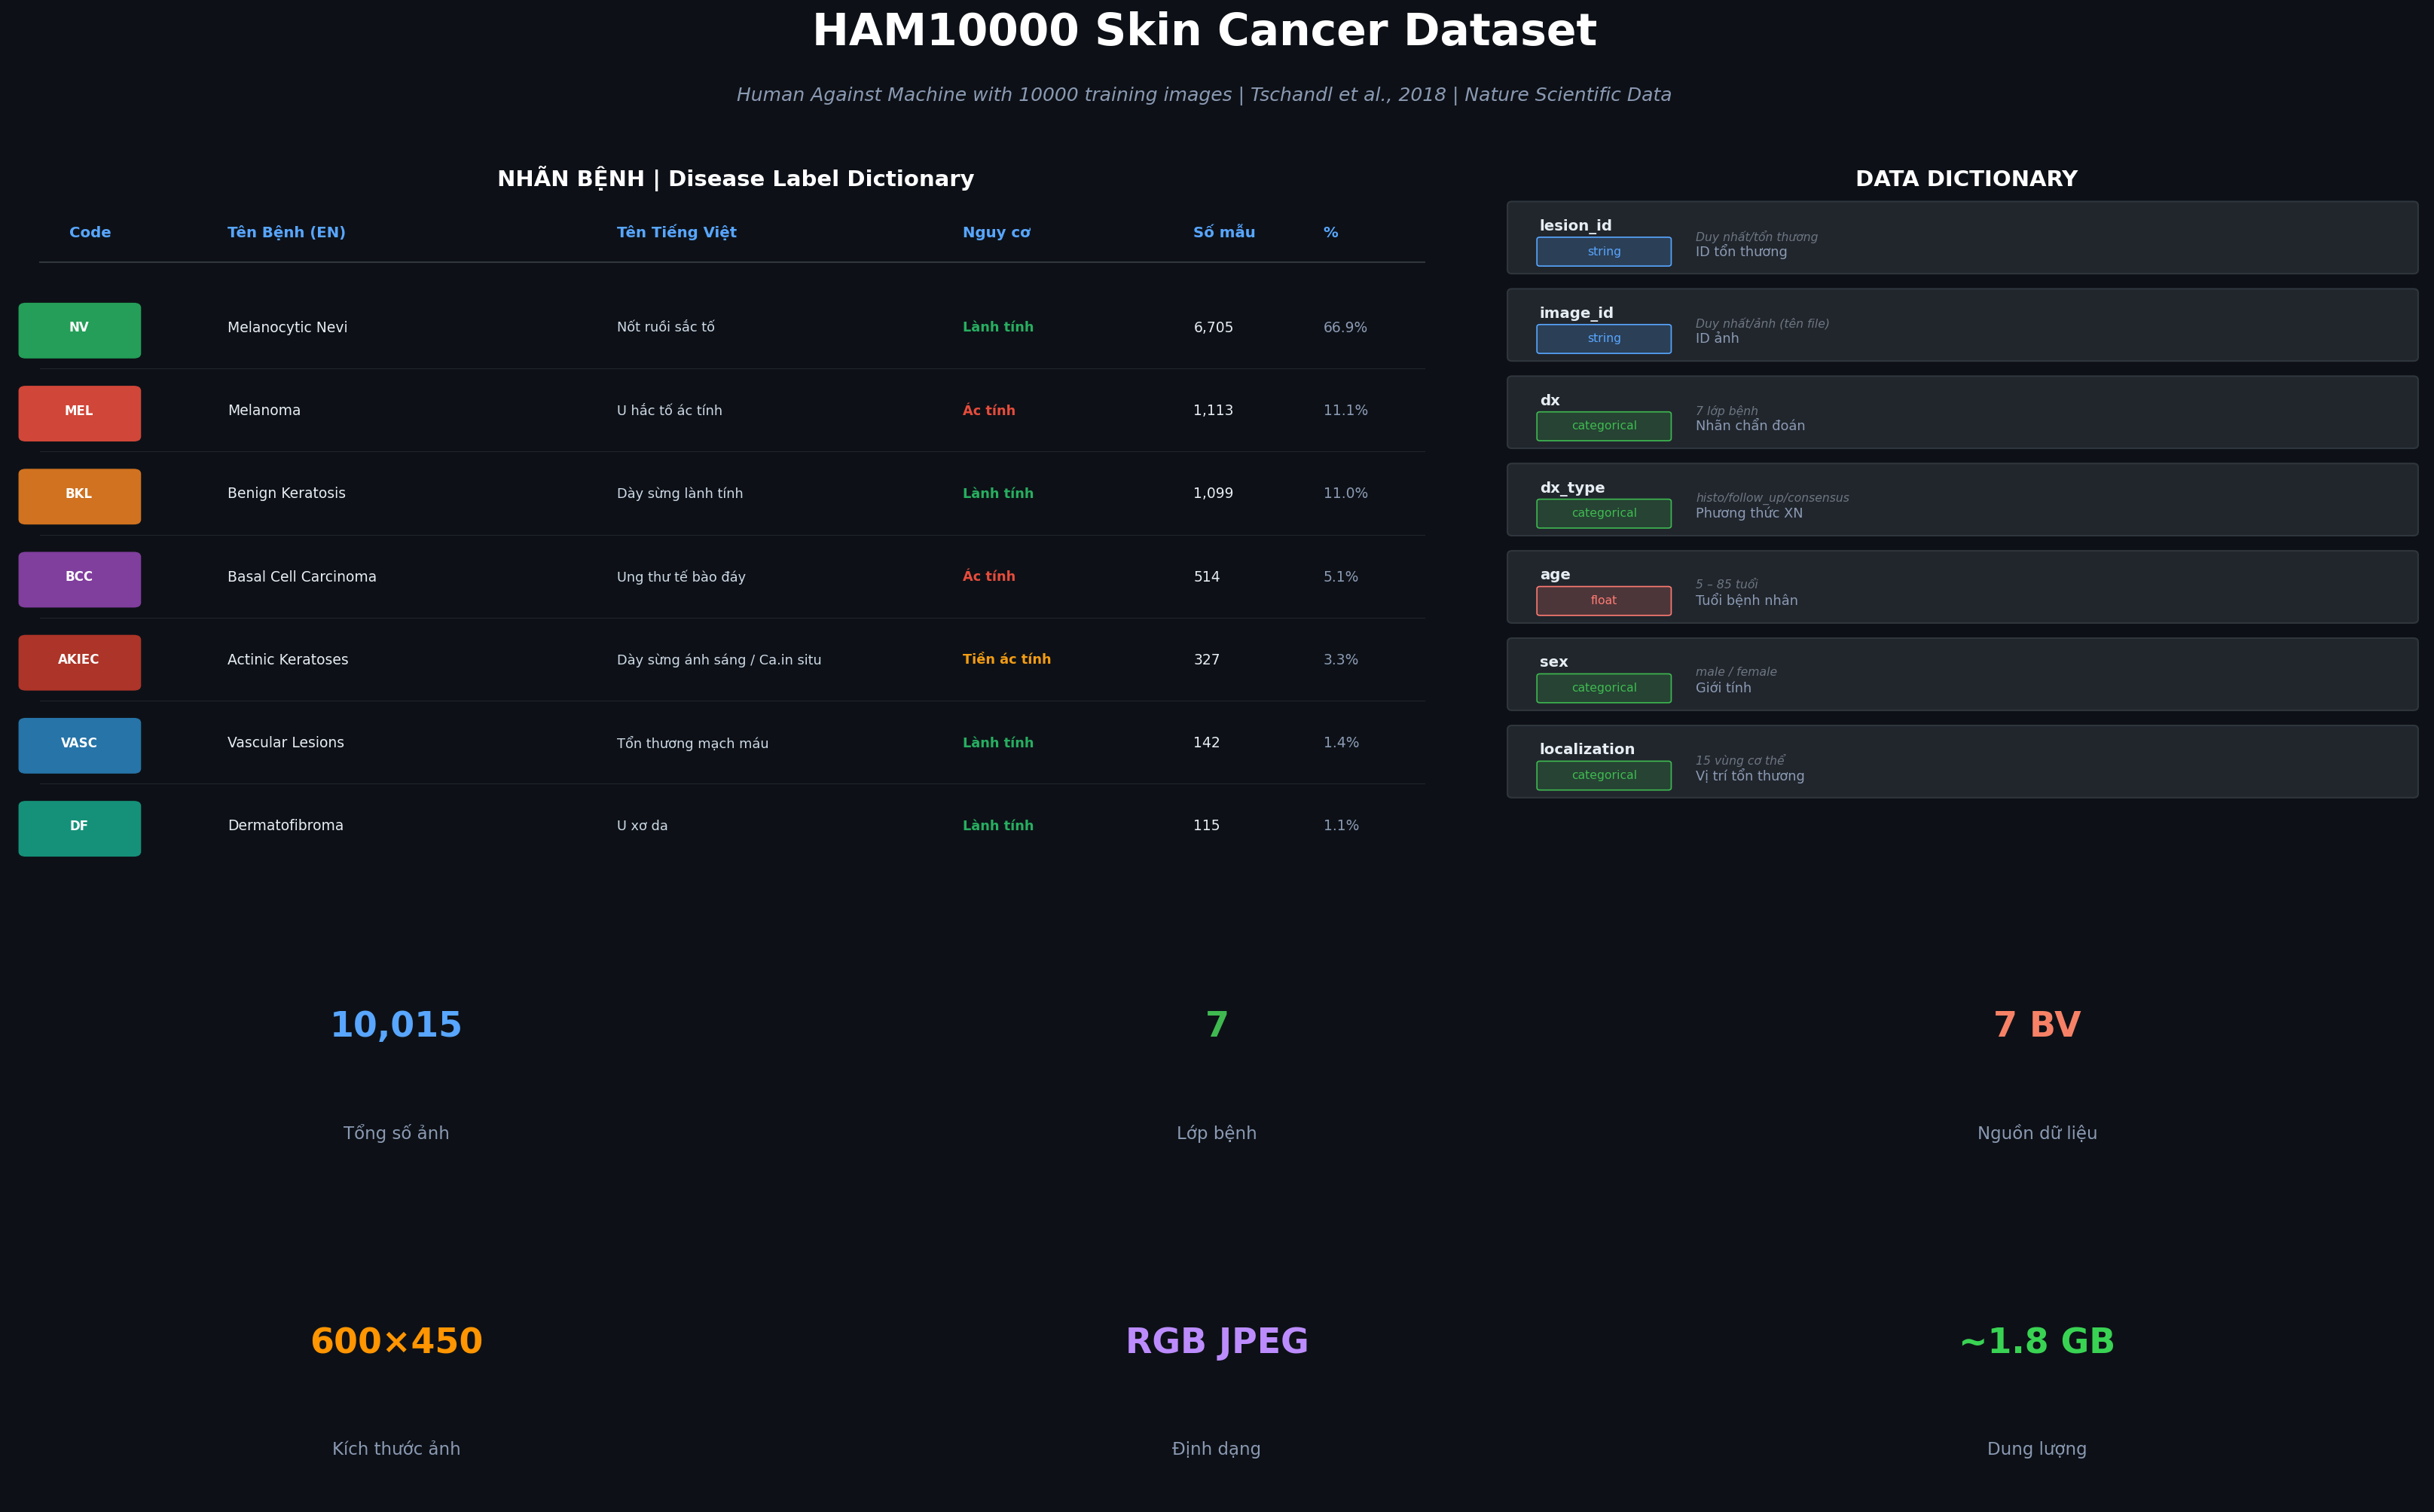

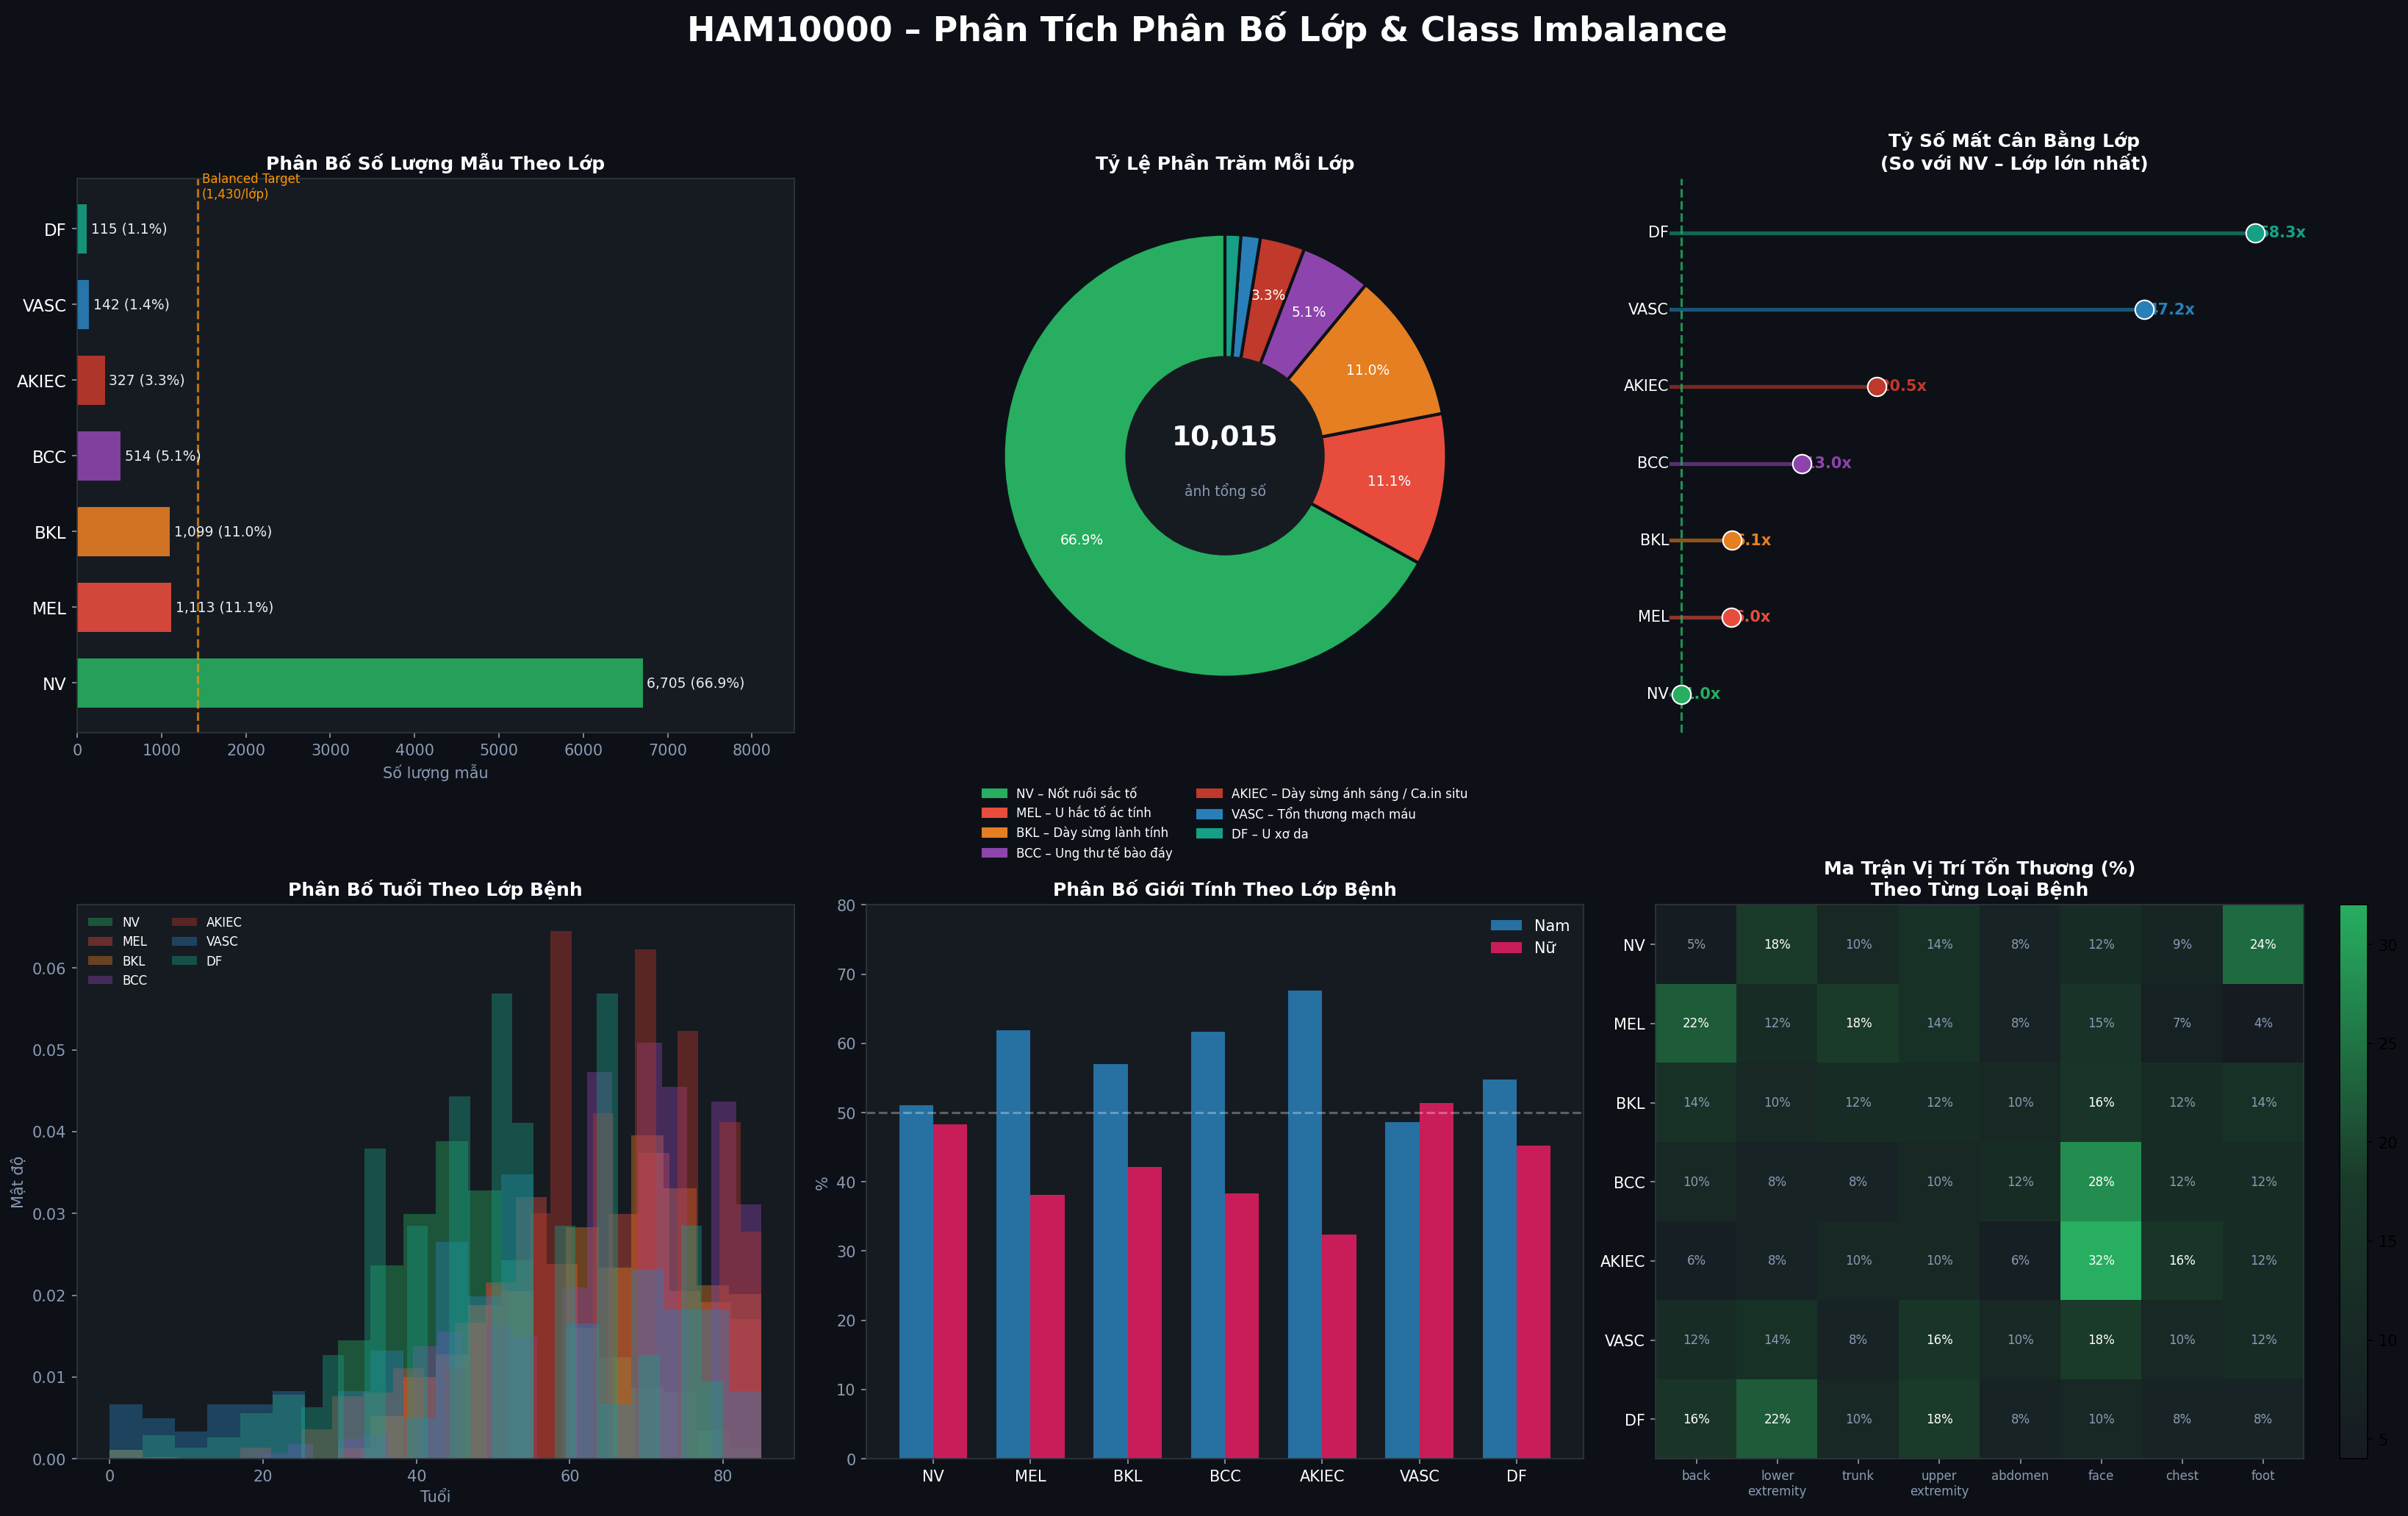

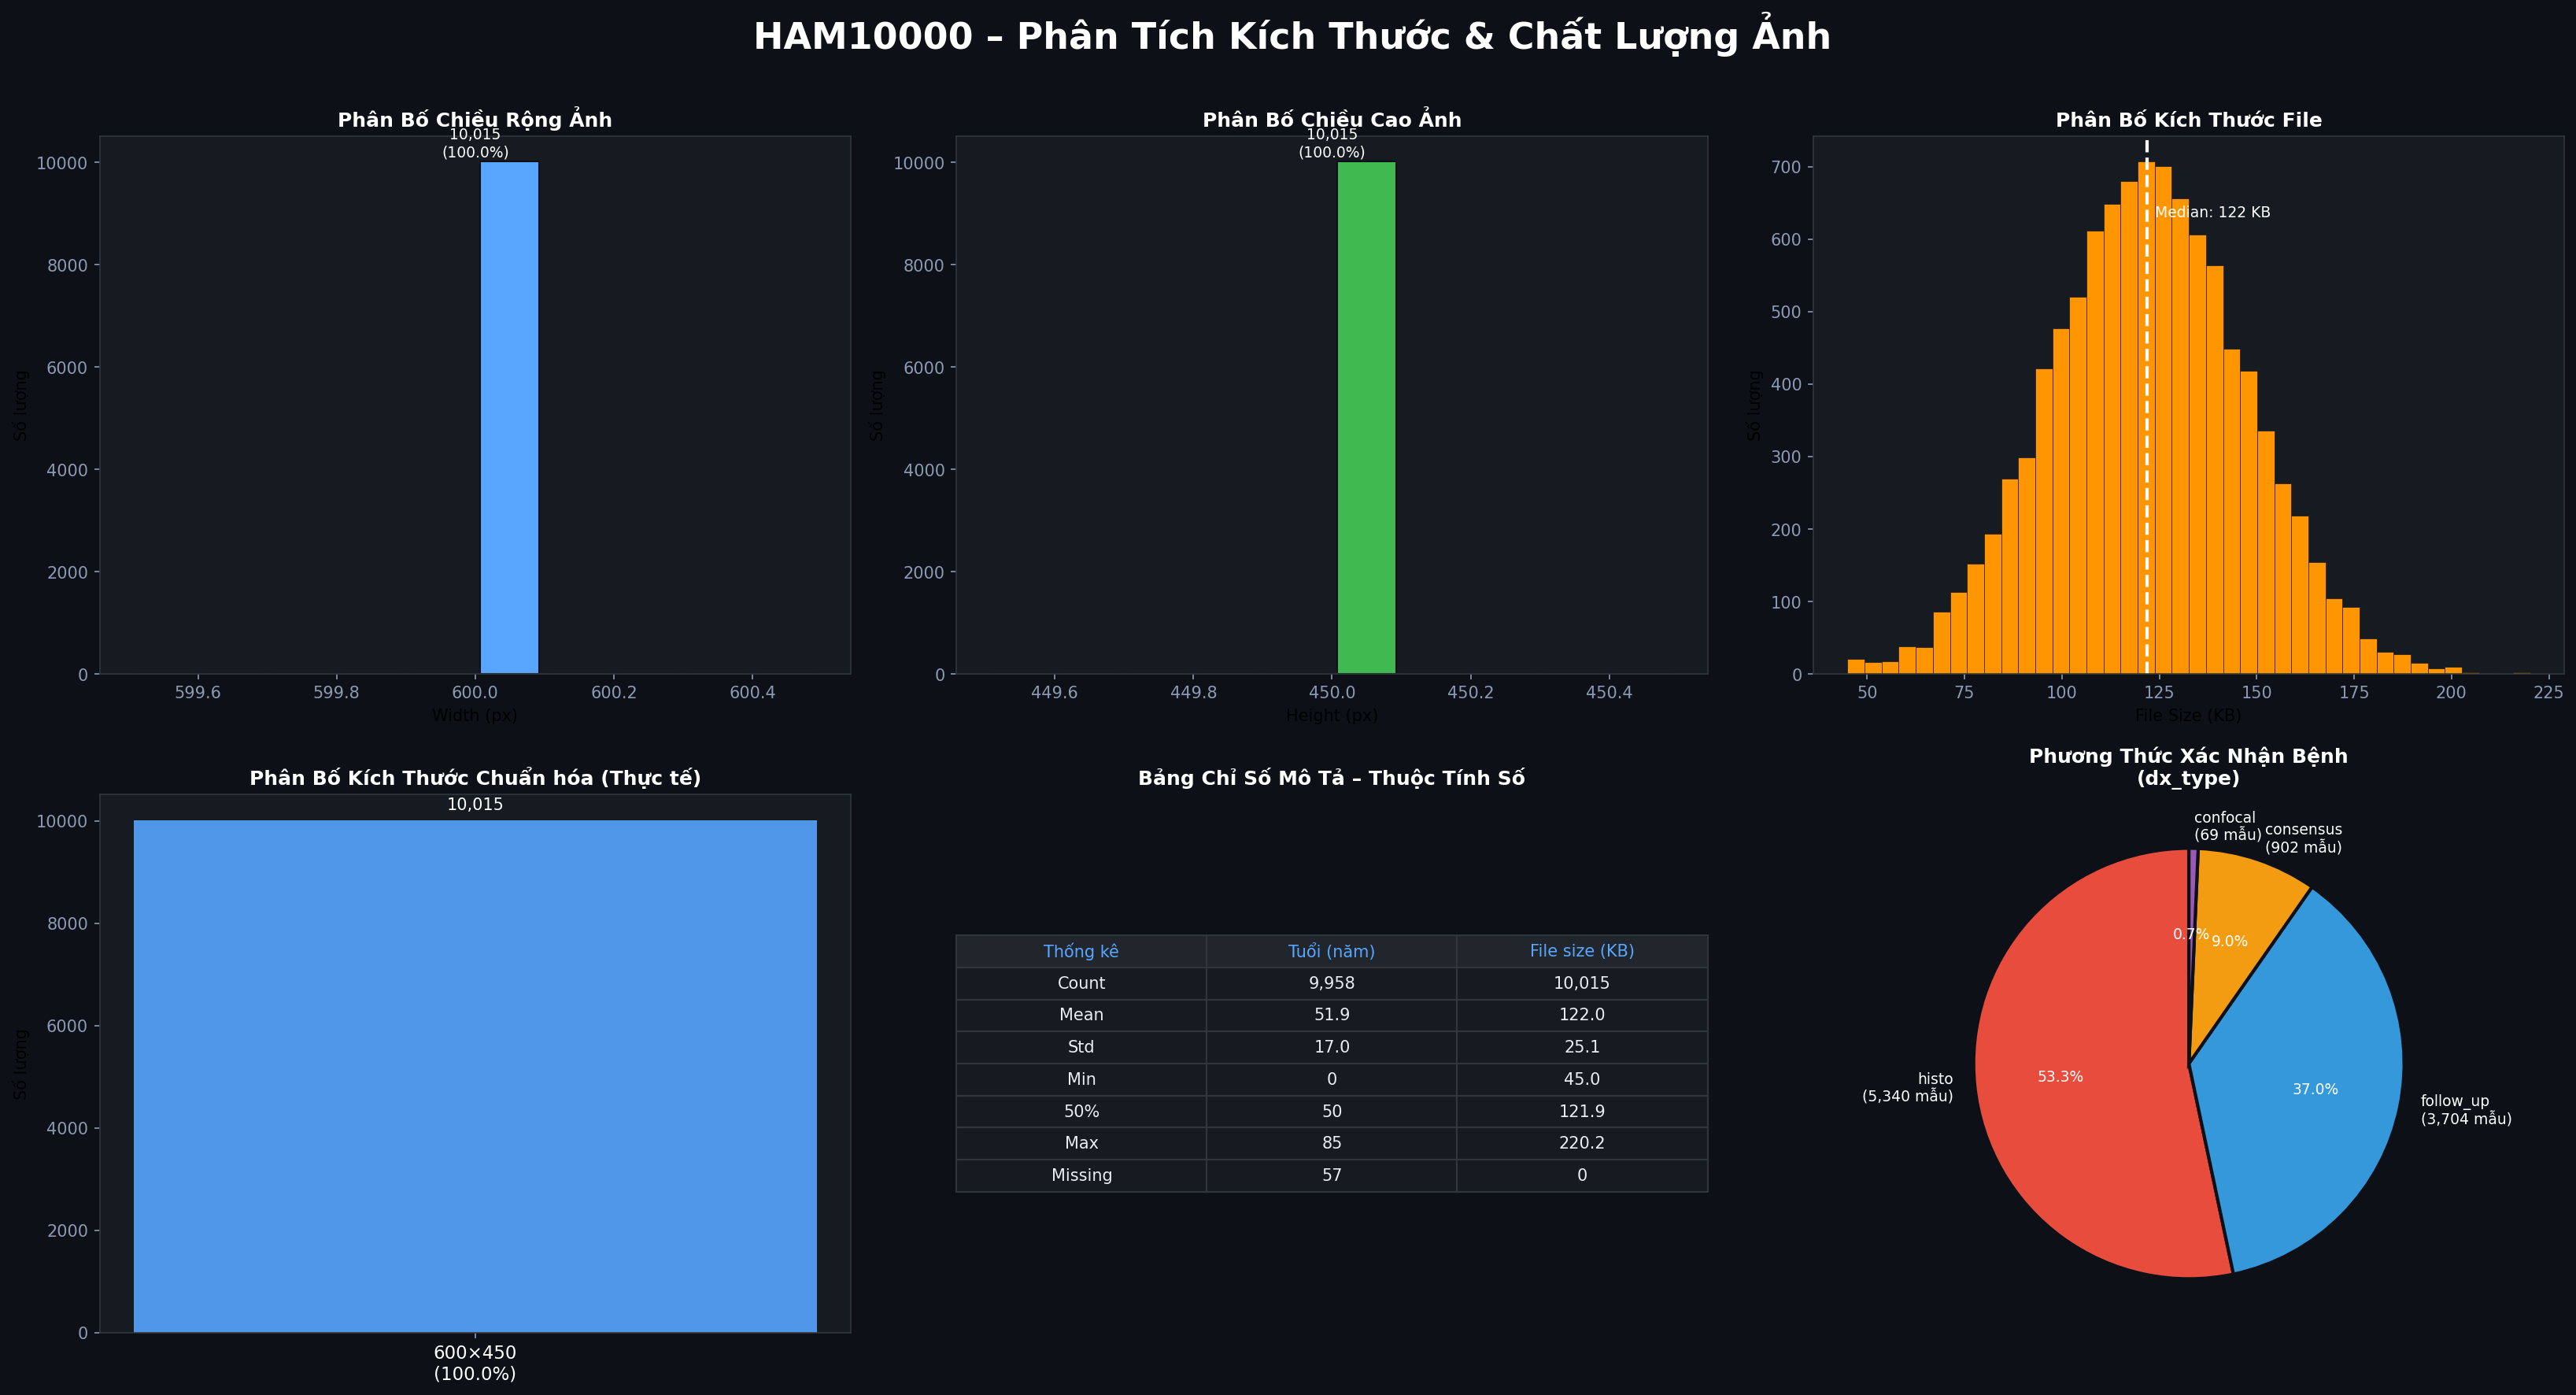

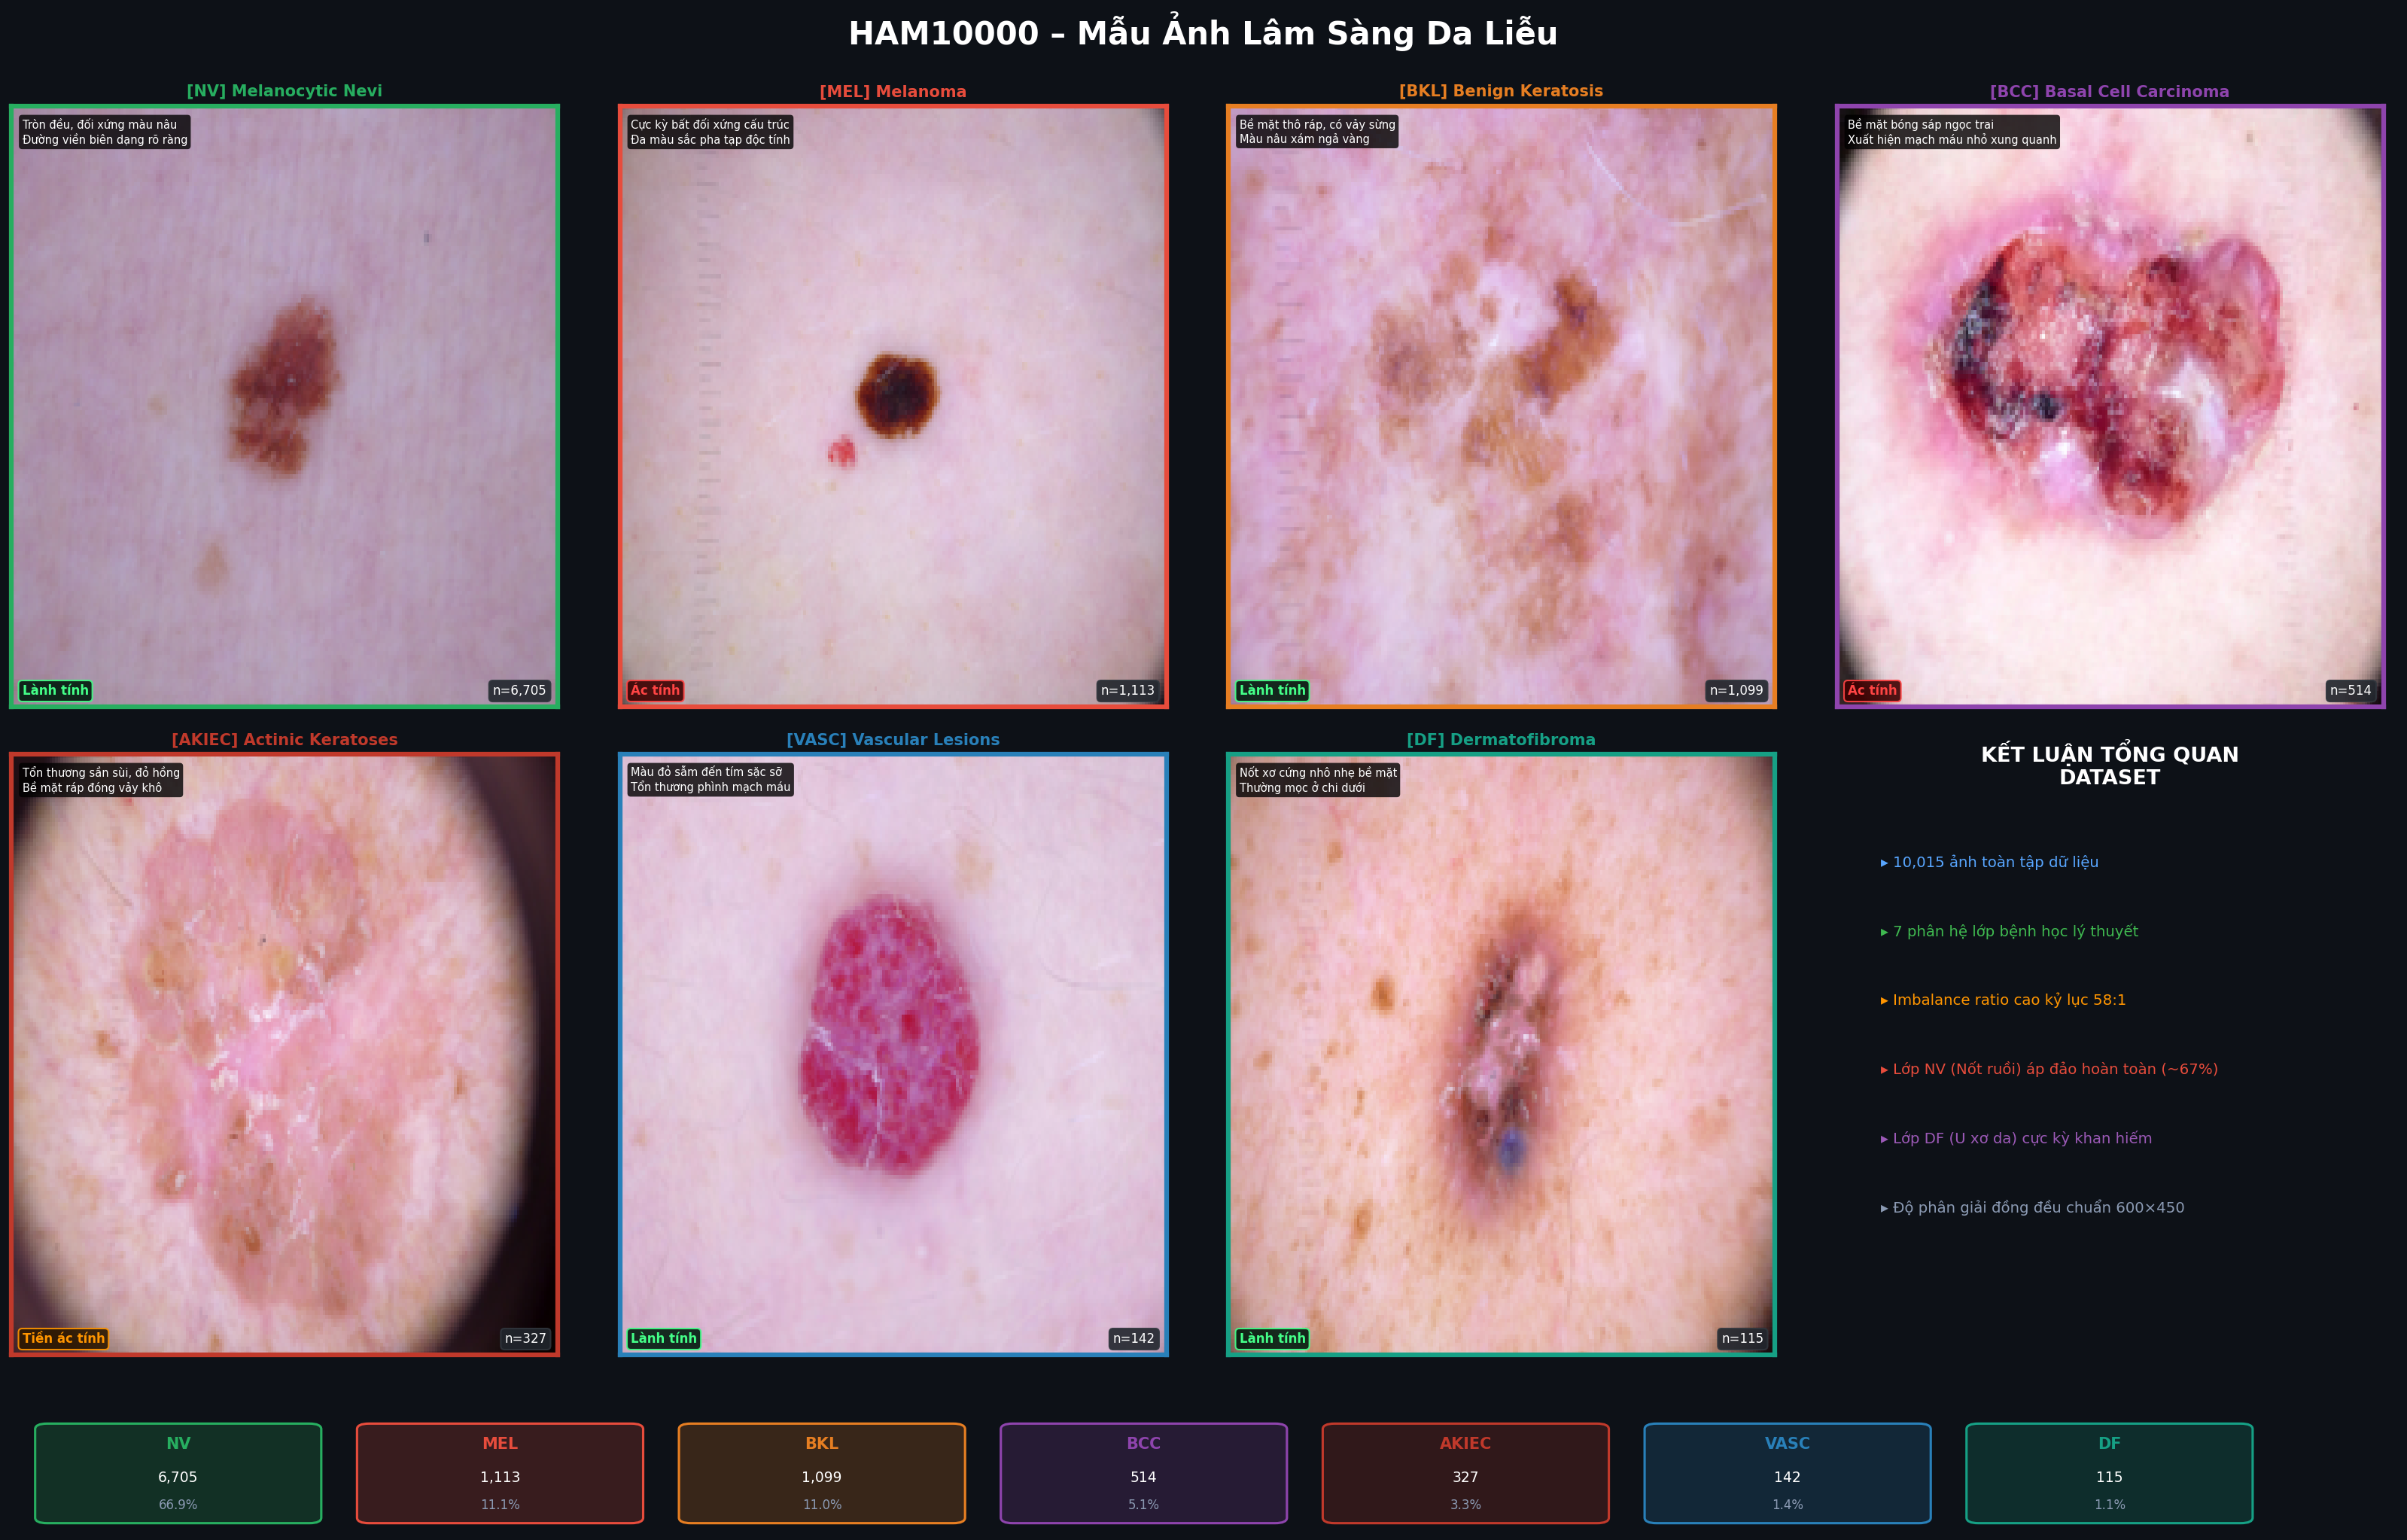

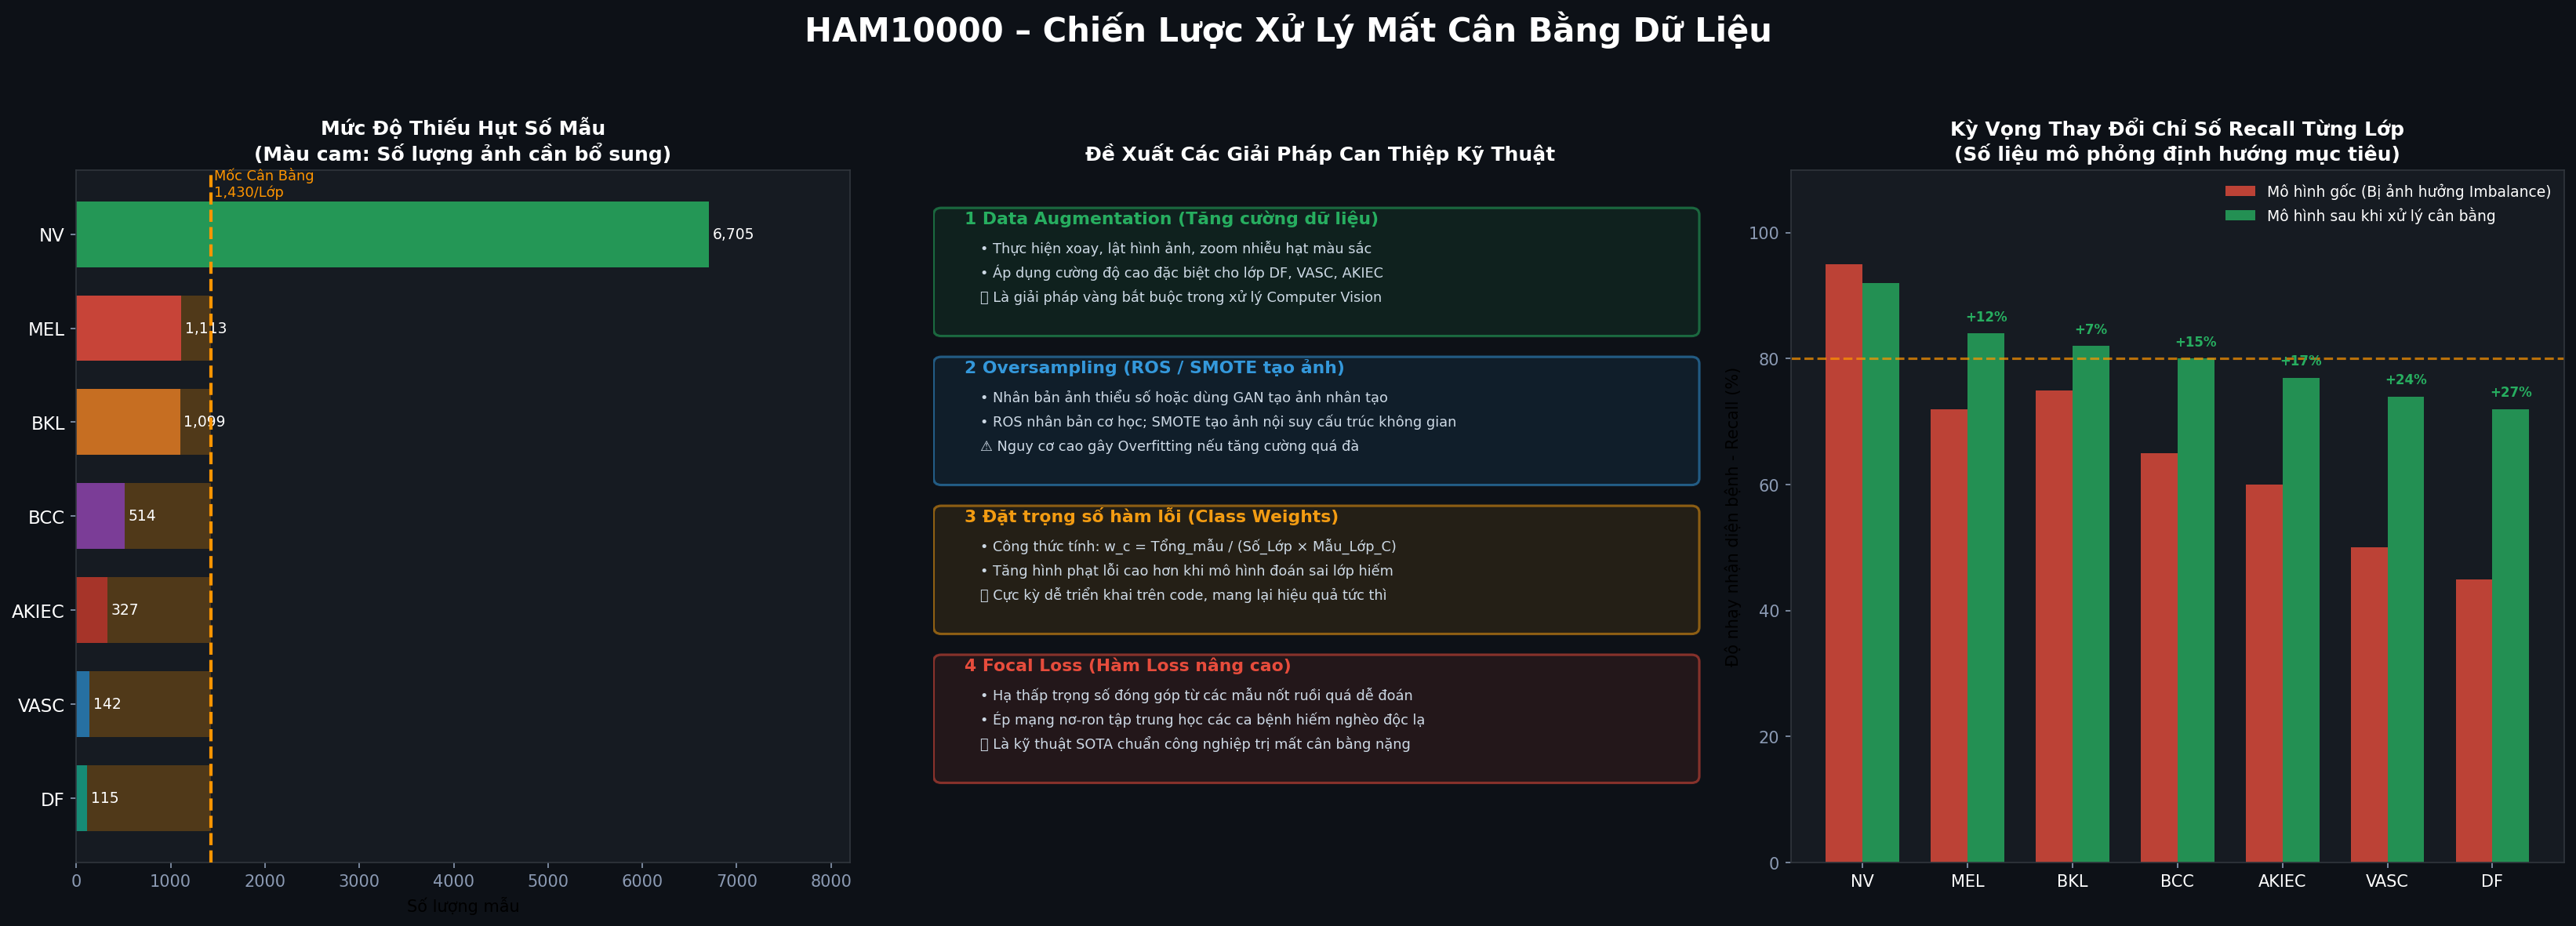

In [21]:
from IPython.display import display, Image as IPythonImage
bieu_do_files = [
    "fig1_data_dictionary.png",
    "fig2_class_distribution.png",
    "fig3_image_size_analysis.png",
    "fig4_sample_visualization.png",
    "fig5_imbalance_analysis.png"
]
for file_name in bieu_do_files:
    path = os.path.join(OUTPUT_DIR, file_name)
    if os.path.exists(path):

        display(IPythonImage(filename=path, width=1000))
    else:
        print(f"⚠️ Chưa tìm thấy file {file_name}, Hãy chạy ô vẽ biểu đồ trước nhé!")